# MNIST Pipeline — Run, Analyze, Plot

Self-contained guide for the MNIST **alpha experiments** at
`mnist_full_r12 / nat / legendre / d3r20c64` (Legendre embedding, in_dim 3,
bond_dim 20, complex64, 64-class) plus the matching adversarially-trained (`at`) model.

| Figure | What it shows |
|--------|---------------|
| Fig 1 | Sampling: per-class mean sampled digit (from the $\alpha=0.01$ model) |
| Fig 2 | Alpha curve: accuracy / robustness + NLL vs $\alpha$ |
| Fig 3 | Robustness curves: robust acc vs attack $\varepsilon$ — 4 models, plus per-model purification & detection overlays |

**Prerequisites**: `conda activate bm4tc`, launch Jupyter, run cells top-to-bottom.
The nat alpha sweeps are already trained + analyzed; `at` is yours to run (§0b).

**Sections**: §0 run · §0b at · §1 analyze + config · §2–4 figures.

In [1]:
import sys
from pathlib import Path

# This notebook lives in notebooks/; Jupyter's CWD is that folder. Walk up to the
# repo root (the dir containing src/) so all outputs/analysis/figures paths resolve.
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
print(f"PROJECT_ROOT = {PROJECT_ROOT}")

PROJECT_ROOT = /home/martin-lanigo/projects/bm4tc


In [2]:
import matplotlib

# Paper styling: Times New Roman via LaTeX (mathptmx). Requires a system LaTeX install
# (latex + dvipng); set USE_LATEX = False to fall back to matplotlib mathtext.
USE_LATEX = True
if USE_LATEX:
    matplotlib.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times"],
        "text.latex.preamble": r"\usepackage{mathptmx}",
    })
else:
    matplotlib.rcParams.update({"text.usetex": False})

PCT = r"\%" if USE_LATEX else "%"   # '%' is a comment char under usetex; escape it in labels

---
## §0  Run the nat alpha experiments

The 3-stage alpha-HPO pipeline: discriminative HPO ($\alpha=0$) → warm-started
generative HPO ladder (sweeps `lr` + `norm_control.soft_strength`) → fill best HPs
→ seed sweeps. These are **already trained** for the current state; the cell prints
the commands for reproduction. Run from the project root.

In [3]:
ARCH = "mnist_full_r12/nat/legendre/d3r20c64"
NAT_PRETRAINED = ["hpo_pretrained_a001", "hpo_pretrained_a01",
                  "hpo_pretrained_a02", "hpo_pretrained_a05", "hpo_pretrained_a1"]
SEED_SWEEPS = ["seed_sweep_a0", "seed_sweep_a001", "seed_sweep_a01",
               "seed_sweep_a02", "seed_sweep_a05", "seed_sweep_a1"]

print("# Stage 1 - discriminative HPO (alpha=0, from scratch, sweeps lr):")
print(f"python -m experiments.train --multirun +experiments={ARCH}/hpo_a0")

print("\n# Stage 2 - warm-started generative HPO ladder (sweeps lr + soft_strength):")
print("#   first set +model_path=outputs/.../hpo_a0_DDMM/0/models/model in each config.")
for k in NAT_PRETRAINED:
    print(f"python -m experiments.train --multirun +experiments={ARCH}/{k}")

print("\n# Stage 3 - bake best HPs into the seed_sweep configs:")
print("python tools/fill_hpo.py --trainer nat --dataset mnist_full_r12 "
      "--embedding legendre --arch d3r20c64")

print("\n# Stage 3 - run the seed sweeps (5 seeds each):")
for k in SEED_SWEEPS:
    print(f"python -m experiments.train --multirun +experiments={ARCH}/{k}")

# Stage 1 - discriminative HPO (alpha=0, from scratch, sweeps lr):
python -m experiments.train --multirun +experiments=mnist_full_r12/nat/legendre/d3r20c64/hpo_a0

# Stage 2 - warm-started generative HPO ladder (sweeps lr + soft_strength):
#   first set +model_path=outputs/.../hpo_a0_DDMM/0/models/model in each config.
python -m experiments.train --multirun +experiments=mnist_full_r12/nat/legendre/d3r20c64/hpo_pretrained_a001
python -m experiments.train --multirun +experiments=mnist_full_r12/nat/legendre/d3r20c64/hpo_pretrained_a01
python -m experiments.train --multirun +experiments=mnist_full_r12/nat/legendre/d3r20c64/hpo_pretrained_a02
python -m experiments.train --multirun +experiments=mnist_full_r12/nat/legendre/d3r20c64/hpo_pretrained_a05
python -m experiments.train --multirun +experiments=mnist_full_r12/nat/legendre/d3r20c64/hpo_pretrained_a1

# Stage 3 - bake best HPs into the seed_sweep configs:
python tools/fill_hpo.py --trainer nat --dataset mnist_full_r12 --embedding legendr

---
## §0b  Run the adversarially-trained (`at`) model

The `at` model warm-starts from the best $\alpha=0$ checkpoint, so run it **after**
`seed_sweep_a0`. It is **not yet trained** — Fig 3's `AT` line stays absent until you do.

In [4]:
AT_ARCH = "mnist_full_r12/at/legendre/d3r20c64"
A0_DIR  = "outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a0_1206"

print("# Step 1 - point the at configs' model_path at the real a0 run dir:")
print(f"python tools/patch_checkpoint.py {A0_DIR}")
print("#   (patches both at/hpo.yaml and at/seed_sweep.yaml by default)")

print("\n# Step 2 - [optional] at HPO + fill (skip if seed_sweep.yaml HPs are already filled):")
print(f"python -m experiments.train --multirun +experiments={AT_ARCH}/hpo")
print("python tools/fill_hpo.py --trainer at --dataset mnist_full_r12 "
      "--embedding legendre --arch d3r20c64")

print("\n# Step 3 - run the at seed sweep (5 seeds):")
print(f"python -m experiments.train --multirun +experiments={AT_ARCH}/seed_sweep")

# Step 1 - point the at configs' model_path at the real a0 run dir:
python tools/patch_checkpoint.py outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a0_1206
#   (patches both at/hpo.yaml and at/seed_sweep.yaml by default)

# Step 2 - [optional] at HPO + fill (skip if seed_sweep.yaml HPs are already filled):
python -m experiments.train --multirun +experiments=mnist_full_r12/at/legendre/d3r20c64/hpo
python tools/fill_hpo.py --trainer at --dataset mnist_full_r12 --embedding legendre --arch d3r20c64

# Step 3 - run the at seed sweep (5 seeds):
python -m experiments.train --multirun +experiments=mnist_full_r12/at/legendre/d3r20c64/seed_sweep


---
## §1  Analyze + configure output dirs

`analysis/sweep.py` turns each multirun output dir into an `evaluation_data.csv`
(one row per seed: `acc`, `rob/{eps}`, `uq_purify_acc/{eps}/{r}`, detection columns, NLL).
Pass `--viz` to also emit the best-run sampling plot used by Fig 1.

Fill `SWEEP_DIRS` with your dated output dirs (`{kind}_{DDMM}`). The nat entries below are
the current trained runs; `at_seed_sweep` is a placeholder — fill it after §0b.

In [5]:
# Dated output dirs ({kind}_{DDMM}). nat dirs are the current trained runs.
SWEEP_DIRS = {
    "seed_sweep_a0":   "outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a0_1206",
    "seed_sweep_a001": "outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a001_1206",
    "seed_sweep_a01":  "outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a01_1206",
    "seed_sweep_a02":  "outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a02_1306",
    "seed_sweep_a05":  "outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a05_1306",
    "seed_sweep_a1":   "outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a1_1206",
    "at_seed_sweep":   "outputs/mnist_full_r12/at/legendre/d3r20c64/seed_sweep_DDMM",  # fill after §0b
}

# Alpha ladder: maps each nat seed sweep to its alpha value.
ALPHA_OF = {
    "seed_sweep_a0": 0.0, "seed_sweep_a001": 0.01, "seed_sweep_a01": 0.1,
    "seed_sweep_a02": 0.2, "seed_sweep_a05": 0.5, "seed_sweep_a1": 1.0,
}

VIZ_SWEEPS = {"seed_sweep_a001"}  # Fig 1 samples from the alpha=0.01 model

print("# Analysis commands (run from project root):")
for name, sweep_dir in SWEEP_DIRS.items():
    viz = " --viz" if name in VIZ_SWEEPS else ""
    print(f"python analysis/sweep.py {sweep_dir}{viz}")

# Analysis commands (run from project root):
python analysis/sweep.py outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a0_1206
python analysis/sweep.py outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a001_1206 --viz
python analysis/sweep.py outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a01_1206
python analysis/sweep.py outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a02_1306
python analysis/sweep.py outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a05_1306
python analysis/sweep.py outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a1_1206
python analysis/sweep.py outputs/mnist_full_r12/at/legendre/d3r20c64/seed_sweep_DDMM


---
## §2  Figure 1 — Sampling (the $\alpha=0.01$ model)

Per-class **mean** sampled digit in a 2×5 grid (digits 0–9), via
`analysis/visualize/mnist_samples.py`. Uses the best (highest clean-acc) run of the
$\alpha=0.01$ seed sweep — the smallest nonzero alpha, where samples first become legible.
Output: `figures/mnist/sampling/mnist_samples.png`.

> Sampling 785 sites is heavy on CPU; drop `n_per_class` for a quick check.

INFO:analysis.utils.mia_utils:Found checkpoint: /home/martin-lanigo/projects/bm4tc/outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a001_1206/4/models/model


Best alpha=0.01 run: /home/martin-lanigo/projects/bm4tc/outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a001_1206/4  (acc=0.9690, device=cuda)


INFO:analysis.visualize.mnist_samples:Loaded model from /home/martin-lanigo/projects/bm4tc/outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep_a001_1206/4/models/model


INFO:analysis.visualize.mnist_samples:Sampled 640 images (64 per class)


INFO:analysis.visualize.mnist_samples:Saved to /home/martin-lanigo/projects/bm4tc/figures/mnist/sampling/mnist_samples.png


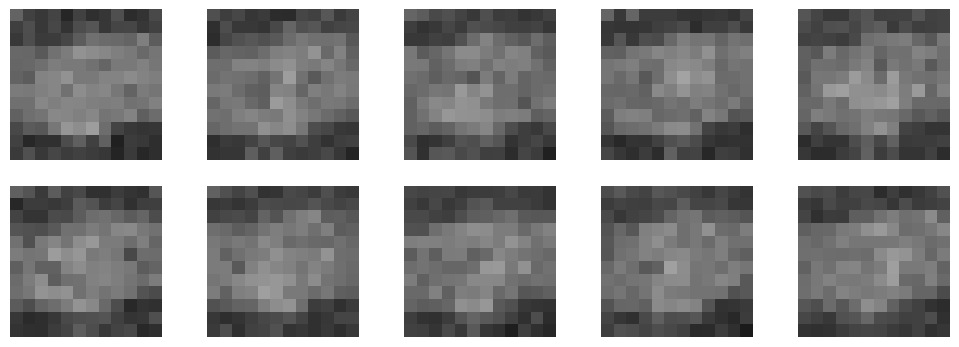

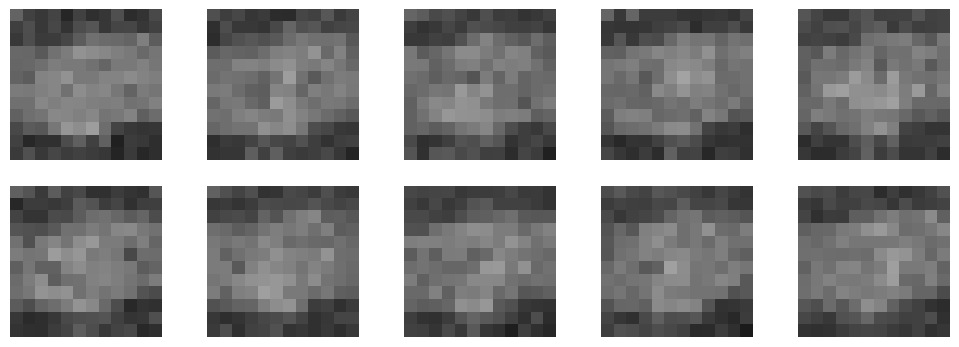

In [6]:
import pandas as pd
import torch
from analysis.utils import get_best_run
from analysis.visualize.mnist_samples import sample_and_plot

SAMPLE_KEY = "seed_sweep_a001"   # alpha = 0.01
N_PER_CLASS = 64                 # lower (e.g. 8) for a fast sanity check
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"  # force "cpu" if your CUDA runtime is stale

csv  = PROJECT_ROOT / "analysis" / SWEEP_DIRS[SAMPLE_KEY] / "evaluation_data.csv"
df   = pd.read_csv(csv)
best = get_best_run(df, "acc", minimize=False)            # highest clean accuracy
run_dir = PROJECT_ROOT / SWEEP_DIRS[SAMPLE_KEY] / str(best["run_name"])
print(f"Best alpha=0.01 run: {run_dir}  (acc={best['acc']:.4f}, device={DEVICE})")

save_dir = PROJECT_ROOT / "figures/mnist/sampling"
fig = sample_and_plot(str(run_dir), n_per_class=N_PER_CLASS, save_dir=str(save_dir), device=DEVICE)

# Strip titles for paper inclusion (sample_and_plot adds a suptitle + per-cell "Digit c"
# labels; cells are row-major 0-9), then re-save over the file it wrote.
fig.suptitle("")
for ax in fig.axes:
    ax.set_title("")
fig.savefig(save_dir / "mnist_samples.png", dpi=150, bbox_inches="tight")
fig   # display inline

---
## §3  Figure 2 — Alpha curve

Assembled from the six nat seed sweeps ($\alpha \in \{0, 0.01, 0.1, 0.2, 0.5, 1\}$),
aggregating over seeds. Left: clean acc, undefended robustness, and purified robustness
vs $\alpha$. Right: discriminative vs generative NLL vs $\alpha$ (dual axes).
Output: `figures/mnist/alpha/alpha_curve.png`. Missing columns are skipped silently.

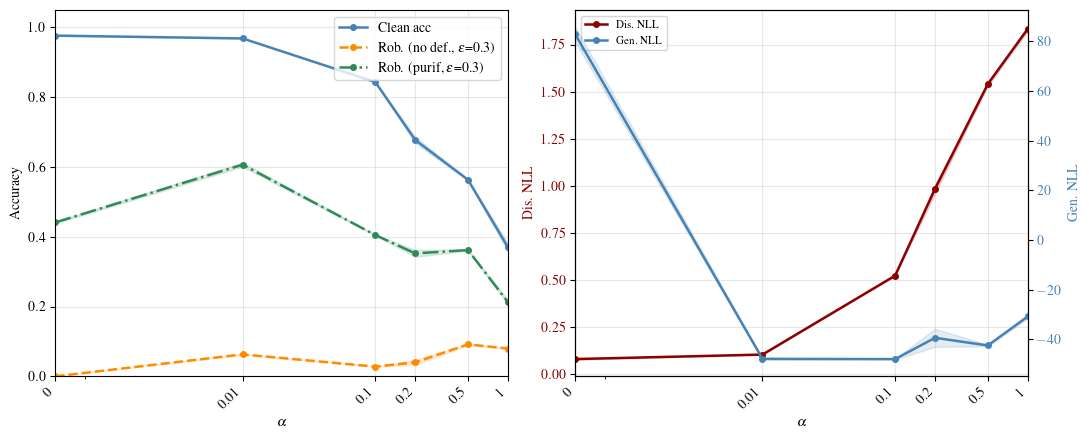

Saved /home/martin-lanigo/projects/bm4tc/figures/mnist/alpha/alpha_curve.png


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

EPS_ALPHA = 0.3                                   # attack budget for the robustness lines
ACC_COL   = "acc"
ROB_COL   = f"rob/{EPS_ALPHA}"
PURIF_COL = f"uq_purify_acc/{EPS_ALPHA}/0.2"
DIS_COL, GEN_COL = "dis_loss", "gen_loss"

NAT_KEYS = ["seed_sweep_a0", "seed_sweep_a001", "seed_sweep_a01",
            "seed_sweep_a02", "seed_sweep_a05", "seed_sweep_a1"]

rows = []
for key in NAT_KEYS:
    p = PROJECT_ROOT / "analysis" / SWEEP_DIRS[key] / "evaluation_data.csv"
    if not p.exists():
        print(f"skip (missing): {p}"); continue
    d = pd.read_csv(p)
    d["alpha"] = ALPHA_OF[key]
    rows.append(d)
df = pd.concat(rows, ignore_index=True)


def agg(col):
    if col not in df.columns:
        return None
    g = df.groupby("alpha")[col].agg(["mean", "std", "count"]).sort_index()
    se = g["std"].fillna(0) / np.sqrt(g["count"].clip(lower=1))
    return g.index.values, g["mean"].values, se.values


def plot_line(ax, res, label, color, ls="-"):
    if res is None:
        return
    a, m, s = res
    ax.plot(a, m, color=color, linestyle=ls, linewidth=1.8, marker="o", ms=4, label=label)
    ax.fill_between(a, m - s, m + s, color=color, alpha=0.15)


_TICKS  = [0, 0.01, 0.1, 0.2, 0.5, 1.0]
_LABELS = ["0", "0.01", "0.1", "0.2", "0.5", "1"]


def setup_xaxis(ax):
    ax.set_xscale("symlog", linthresh=5e-3)
    ax.set_xlim(0, 1)
    ax.set_xticks(_TICKS)
    ax.set_xticklabels(_LABELS, rotation=45, ha="right", fontsize=10)


fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(11, 4.5))

plot_line(ax_l, agg(ACC_COL),   "Clean acc",                            "steelblue",  "-")
plot_line(ax_l, agg(ROB_COL),   rf"Rob. (no def., $\varepsilon$={EPS_ALPHA})", "darkorange", "--")
plot_line(ax_l, agg(PURIF_COL), rf"Rob. (purif, $\varepsilon$={EPS_ALPHA})",   "seagreen",   "-.")
ax_l.set_xlabel(r"$\alpha$"); ax_l.set_ylabel("Accuracy")
setup_xaxis(ax_l); ax_l.set_ylim(0, 1.05); ax_l.legend(fontsize=10); ax_l.grid(True, alpha=0.3)

ax_r2 = ax_r.twinx()
plot_line(ax_r,  agg(DIS_COL), "Dis. NLL", "darkred",   "-")
plot_line(ax_r2, agg(GEN_COL), "Gen. NLL", "steelblue", "-")
ax_r.set_xlabel(r"$\alpha$"); ax_r.set_ylabel("Dis. NLL", color="darkred")
ax_r2.set_ylabel("Gen. NLL", color="steelblue")
ax_r.tick_params(axis="y", labelcolor="darkred"); ax_r2.tick_params(axis="y", labelcolor="steelblue")
setup_xaxis(ax_r); ax_r.grid(True, alpha=0.3)
lines = ax_r.get_lines() + ax_r2.get_lines()
if lines:
    ax_r.legend(lines, [l.get_label() for l in lines], fontsize=8)

fig.tight_layout()
out = PROJECT_ROOT / "figures/mnist/alpha/alpha_curve.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show(); print(f"Saved {out}")

---
## §4  Figure 3 — Defense comparison (model × defense, per attack strength)

One standalone grouped bar chart **per attack $\varepsilon$** (the $\varepsilon$ value is
encoded in the filename, not a title). Within each: x = model ($\alpha=0,\,0.01,\,0.5$, and
`AT`), bar groups compare defenses, ±std error bars over seeds:

- **Clean acc** — reference (`acc`, $\varepsilon$-independent).
- **No defense** — undefended adversarial accuracy (`rob/{eps}`).
- **Purification** — likelihood purification (`uq_purify_acc/{eps}/0.2`).
- **Accept (FPR 5%)** — accuracy on inputs the likelihood detector does *not* flag,
  $1-$`uq_det_err_passed/5pct/{eps}` (threshold = 5th percentile of clean $\log p(x)$,
  i.e. ~5% of clean inputs rejected). *Conditional on acceptance*: at large $\varepsilon$
  more inputs are rejected, so high accept-accuracy can come with low coverage
  (see `uq_detection/5pct/{eps}`).

> `uq_joint_*` columns are accuracy under a detector-aware *adaptive* attack, **not** a
> defense — not plotted. Models with no CSV yet (`AT` before §0b) are skipped.
> Outputs: `figures/mnist/robustness/defense_comparison_eps{0.1,0.2,0.3}.png`.

skip (no CSV yet): at_seed_sweep


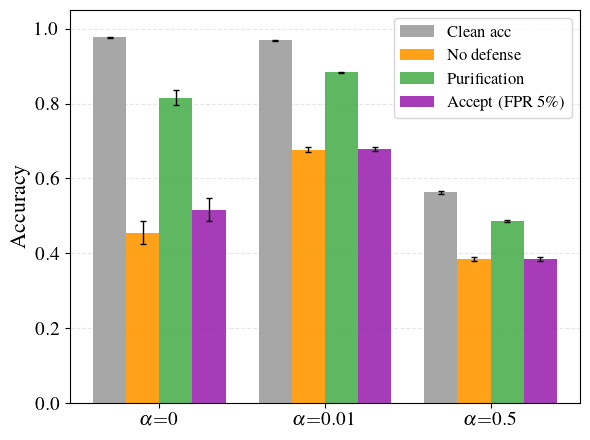

Saved /home/martin-lanigo/projects/bm4tc/figures/mnist/robustness/defense_comparison_eps0.1.png


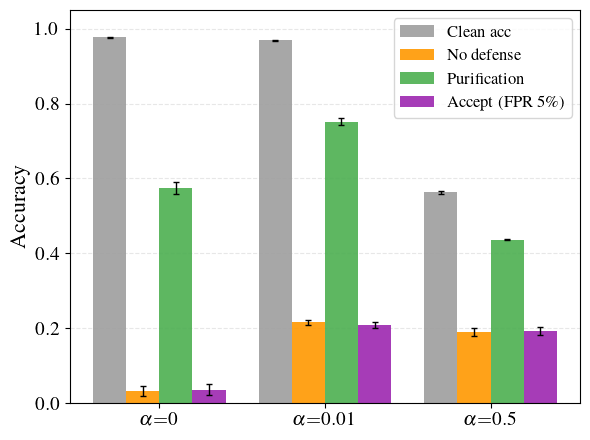

Saved /home/martin-lanigo/projects/bm4tc/figures/mnist/robustness/defense_comparison_eps0.2.png


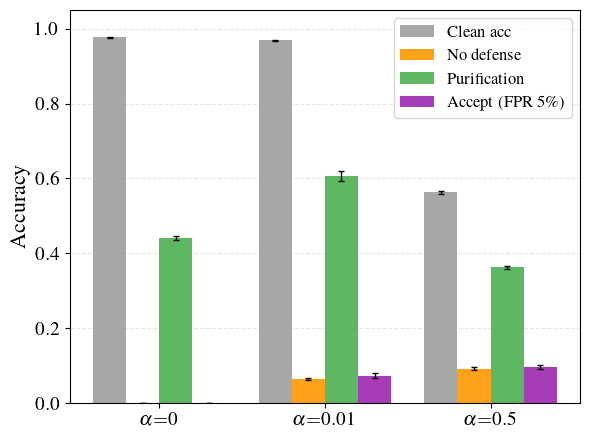

Saved /home/martin-lanigo/projects/bm4tc/figures/mnist/robustness/defense_comparison_eps0.3.png


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Models to compare (x-axis). Defenses are the bar groups.
MODELS = [
    ("seed_sweep_a0",   r"$\alpha{=}0$"),
    ("seed_sweep_a001", r"$\alpha{=}0.01$"),
    ("seed_sweep_a05",  r"$\alpha{=}0.5$"),
    ("at_seed_sweep",   "AT"),
]
# (label, color, column template, flip = use 1 - value).
# Accept-accuracy = 1 - uq_det_err_passed/5pct/{eps}: accuracy on inputs the detector does
# NOT flag, with the threshold at the 5th percentile of clean log p(x) (~5% clean rejected).
DEFENSES = [
    ("Clean acc",            "#9E9E9E", "acc",                          False),
    ("No defense",           "#FF9800", "rob/{eps}",                    False),
    ("Purification",         "#4CAF50", "uq_purify_acc/{eps}/0.2",      False),
    (f"Accept (FPR 5{PCT})", "#9C27B0", "uq_det_err_passed/5pct/{eps}", True),
]

LABEL_FS, TICK_FS, LEG_FS = 16, 14, 12   # axis label / tick / legend font sizes


def load(key):
    p = PROJECT_ROOT / "analysis" / SWEEP_DIRS[key] / "evaluation_data.csv"
    return pd.read_csv(p) if p.exists() else None


def eps_grid(df):
    eps = set()
    for c in df.columns:
        if c.startswith("rob/"):
            try:
                eps.add(float(c.split("/")[1]))
            except ValueError:
                pass
    return sorted(eps)


def stat(df, template, eps, flip):
    col = template.format(eps=eps)
    if col not in df.columns:
        return np.nan, 0.0
    v = pd.to_numeric(df[col], errors="coerce").dropna()
    if flip:
        v = 1.0 - v
    return (v.mean(), v.std() if len(v) > 1 else 0.0)


dfs = {k: load(k) for k, _ in MODELS}
for k, _ in MODELS:
    if dfs[k] is None:
        print(f"skip (no CSV yet): {k}")
avail = [(k, lab) for k, lab in MODELS if dfs[k] is not None]
EPS_LIST = eps_grid(dfs[avail[0][0]])

n_m, n_d = len(avail), len(DEFENSES)
x, width = np.arange(n_m), 0.8 / n_d
outdir = PROJECT_ROOT / "figures/mnist/robustness"
outdir.mkdir(parents=True, exist_ok=True)

# One standalone figure per attack epsilon (eps encoded in the filename).
for eps in EPS_LIST:
    fig, ax = plt.subplots(figsize=(6, 4.5))
    for j, (dlabel, dcolor, tmpl, flip) in enumerate(DEFENSES):
        means, stds = zip(*(stat(dfs[k], tmpl, eps, flip) for k, _ in avail))
        ax.bar(x + (j - (n_d - 1) / 2) * width, means, width, yerr=stds,
               label=dlabel, color=dcolor, capsize=2, alpha=0.9,
               error_kw={"elinewidth": 1})
    ax.set_xticks(x); ax.set_xticklabels([lab for _, lab in avail], fontsize=TICK_FS)
    ax.set_ylabel("Accuracy", fontsize=LABEL_FS)
    ax.tick_params(axis="y", labelsize=TICK_FS)
    ax.set_ylim(0, 1.05); ax.grid(axis="y", alpha=0.3, ls="--"); ax.set_axisbelow(True)
    ax.legend(fontsize=LEG_FS, loc="upper right")
    fig.tight_layout()
    out = outdir / f"defense_comparison_eps{eps}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight"); plt.show(); print(f"Saved {out}")